In [ ]:
# IMPORTACIÓN DE LIBRERIAS
import pandas as pd
from scipy import stats as st
import math  as mt 
import numpy as np
from matplotlib import pyplot as plt
from datetime import datetime as dt
from datetime import timedelta as td
import seaborn as sns

# Lectura, limpieza y preprocesamiento de datos

In [12]:
# ESTANDARIZAR NOMBRES DE COLUMNAS
def clean_colnames(df):
    df.columns = df.columns.str.lower().str.replace(' ','_')
    return df
# CONVERTIR FECHAS AL TIPO ADECUADO
def convert_dtypes(df, col):
    df[col] = pd.to_datetime(df[col], utc=True)
    return df

# LECTURA DE DATOS, ESTANDARIZACIÓN DE LOS NOMBRE DE COLUMNAS, CONVERSIÓN DE DATOS
# ELIMINACIÓN DE DUPLICADOS Y VALORES NULOS EN LAS COLUMNAS OPERADOR_ID E INTERNAL
calls =  pd.read_csv("data/telecom_dataset_new.csv")
calls = clean_colnames(calls).drop_duplicates()
calls["date"] = pd.to_datetime(calls["date"]).dt.tz_localize(None)
loss_data = len(calls)
calls = calls.dropna(subset=['operator_id','internal']) 
loss_data = round((loss_data - len(calls))/loss_data * 100,2)
print(f"Se eliminó el {loss_data}% de las filas con valores nulos en las columnas 'operator_id' e 'internal'")

calls['operator_id'] = calls['operator_id'].astype(int)
calls['internal'] = calls['internal'].astype(bool)
# CREACIÓN DE LA COLUMNA "WAITING_TIME"
calls['waiting_time'] = calls['total_call_duration'] - calls['call_duration']

clients = pd.read_csv("data/telecom_clients.csv")
clients = clean_colnames(clients).drop_duplicates()
clients["date_start"] = pd.to_datetime(clients["date_start"], format='%Y-%m-%d')

display(calls.sample(2))
print(calls['direction'].unique())
print(calls['internal'].unique())
print(calls.info())
display(clients.sample(2))
print(clients['tariff_plan'].unique())
print(clients.info())

print("Descripción estadística de las variables numéricas del dataset de llamadas:")
display(calls.drop(['user_id','operator_id'],axis= 1).describe())
print("Percentiles 90, 95 y 99 de la variable 'calls_count' y 'total_call_duration':")
print(calls['calls_count'].quantile([0.9,0.95,0.99]))
print(calls['total_call_duration'].quantile([0.9,0.95,0.99]))
calls = calls.query('calls_count <= 166 and total_call_duration <=  5036')
display(calls.drop(['user_id','operator_id'],axis= 1).describe())

Se eliminó el 15.33% de las filas con valores nulos en las columnas 'operator_id' e 'internal'


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,waiting_time
52343,168361,2019-11-06,out,False,945322,True,66,0,1902,1902
52558,168361,2019-11-12,out,False,945284,False,64,4627,5737,1110


['out' 'in']
[ True False]
<class 'pandas.core.frame.DataFrame'>
Int64Index: 41491 entries, 1 to 53899
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   user_id              41491 non-null  int64         
 1   date                 41491 non-null  datetime64[ns]
 2   direction            41491 non-null  object        
 3   internal             41491 non-null  bool          
 4   operator_id          41491 non-null  int64         
 5   is_missed_call       41491 non-null  bool          
 6   calls_count          41491 non-null  int64         
 7   call_duration        41491 non-null  int64         
 8   total_call_duration  41491 non-null  int64         
 9   waiting_time         41491 non-null  int64         
dtypes: bool(2), datetime64[ns](1), int64(6), object(1)
memory usage: 2.9+ MB
None


,user_id,tariff_plan,date_start
426,167227,C,2019-09-06
692,166533,B,2019-08-07


['A' 'C' 'B']
<class 'pandas.core.frame.DataFrame'>
Int64Index: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   user_id      732 non-null    int64         
 1   tariff_plan  732 non-null    object        
 2   date_start   732 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 22.9+ KB
None
Descripción estadística de las variables numéricas del dataset de llamadas:


,calls_count,call_duration,total_call_duration,waiting_time
count,41491.000000,41491.000000,41491.000000,41491.000000
mean,16.921381,1010.940011,1323.153238,312.213227
std,59.786187,4066.666485,4788.953155,1176.102940
min,1.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,67.000000,19.000000
50%,4.000000,106.000000,289.000000,60.000000
75%,14.000000,772.000000,1107.000000,219.000000
max,4817.000000,144395.000000,166155.000000,46474.000000


Percentiles 90, 95 y 99 de la variable 'calls_count' y 'total_call_duration':
0.90     37.0
0.95     65.0
0.99    165.1
Name: calls_count, dtype: float64
0.90     2935.0
0.95     5035.5
0.99    13654.1
Name: total_call_duration, dtype: float64


,calls_count,call_duration,total_call_duration,waiting_time
count,39383.000000,39383.000000,39383.000000,39383.000000
mean,10.274687,508.075032,693.094076,185.019044
std,16.875669,865.707436,988.585237,373.063812
min,1.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,62.000000,18.000000
50%,4.000000,86.000000,252.000000,54.000000
75%,11.000000,609.000000,891.000000,179.000000
max,166.000000,4966.000000,5036.000000,5010.000000


Se han retirado las filas con valores duplicados y las filas con valores nulos en las columnas `operator_id` e `internal`. Esto se ha realizado por que los datos en estas columnas son fundamentales para el análisis estdístico posterior, adicionalmente permite coercionar los datos al tipo `int` y `bool`  respectivamente. Este procedimiento eliminó el $15.33\%$ de las filas originales (sin duplicados). Del análisis de percentiles posterior, se conservarán los percentiles, 99 y 95 para las variables `calls_count` y `total_call_duration` respectivamente.

# Análisis exploratorio
---

## Distribuciones generales para `direction`, `internal` y `is_missed_call`

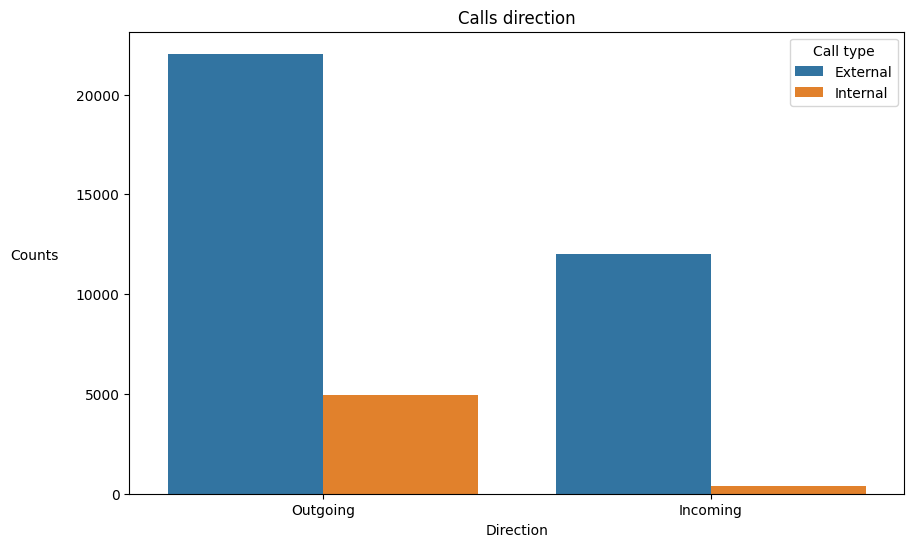

In [18]:
plt.figure(figsize=(10,6))
sns.countplot(x='direction', data=calls, hue='internal')
plt.title('Calls direction')
plt.xlabel('Direction')
plt.ylabel('Counts', rotation=0, labelpad=30)
plt.xticks([0,1], ['Outgoing','Incoming'])
plt.legend(title='Call type', labels=['External', 'Internal'])
plt.show()

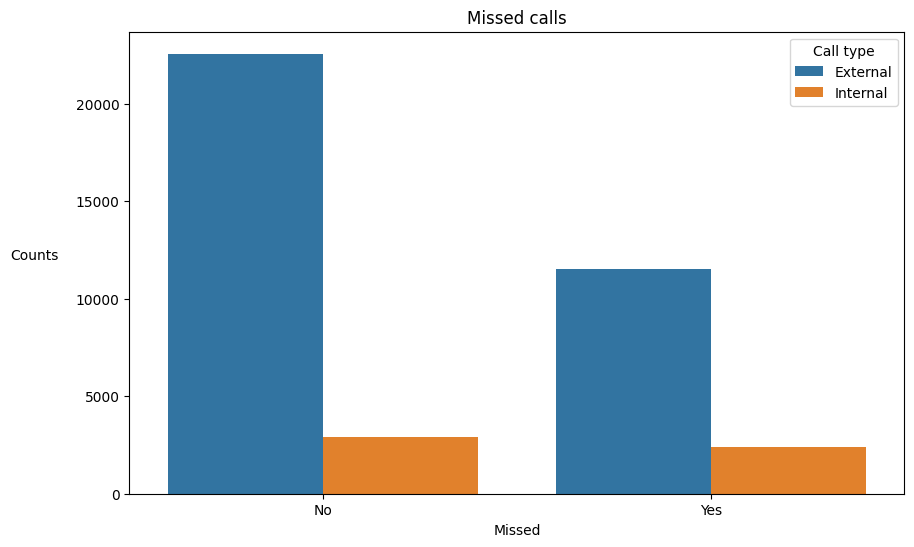

In [19]:
plt.figure(figsize=(10,6))
sns.countplot(x='is_missed_call', data=calls, hue='internal')
plt.title('Missed calls')
plt.xlabel('Missed')
plt.ylabel('Counts', rotation=0, labelpad=30)
plt.xticks([0,1], ['No', 'Yes'])
plt.legend(title='Call type', labels=['External', 'Internal'])
plt.show()

Los graficos anteriores muestran que **la mayor proporción de llamadas son salientes** (cerca del $70\%$, menos del $60\%$ son externas y más del $10\%$ son internas). De igual forma, cerca del $70\%$ de las llamadas (entre internas y externas) son respondidas. 

***
## Distribuciones para `waiting_time`, `calls_count` y volumen de llamadas en el tiempo

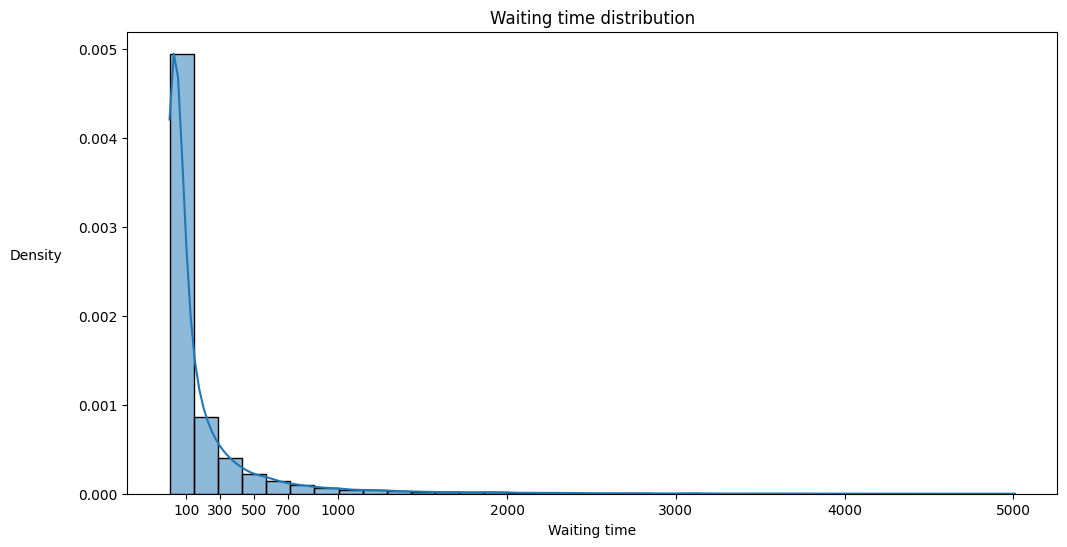

In [23]:
# DISTRIBUCIÓN DE WAITING TIME
plt.figure(figsize=(12,6))
sns.histplot(x='waiting_time', data=calls, bins=35 ,stat='density', kde=True)
plt.title('Waiting time distribution')
plt.xlabel('Waiting time')
plt.ylabel('Density', rotation=0, labelpad=30)
plt.xticks([100, 300, 500, 700, 1000, 2000, 3000, 4000, 5000])
plt.show()

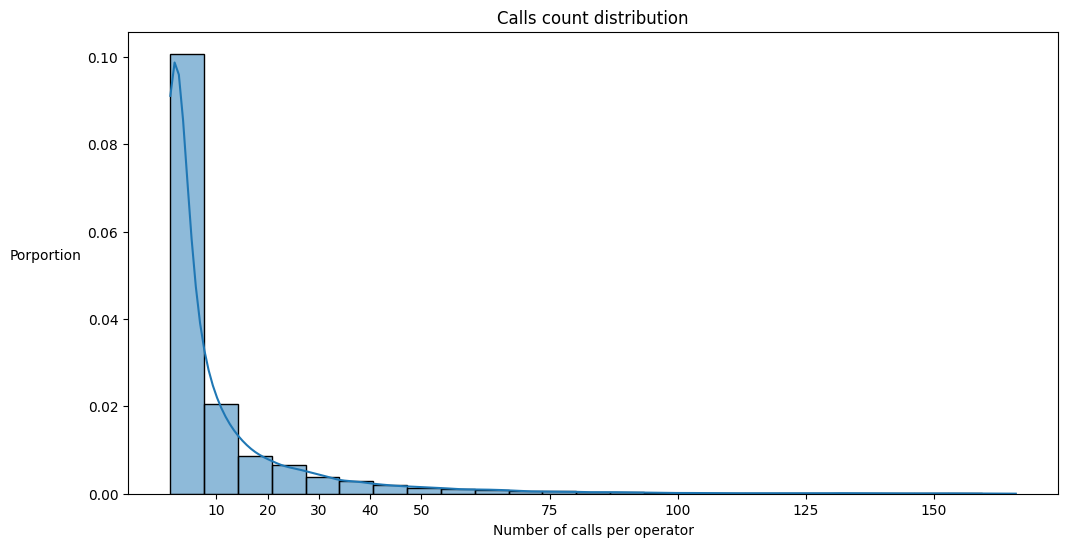

In [22]:
# DISTRIBUCIÓN DE CALLS COUNT
plt.figure(figsize=(12,6))
sns.histplot(x='calls_count', data=calls, bins=25 ,stat='density', kde=True)
plt.title('Calls count distribution')
plt.xlabel('Number of calls per operator')
plt.ylabel('Density', rotation=0, labelpad=30)
plt.xticks([10, 20, 30, 40, 50, 75, 100, 125, 150])
plt.show()

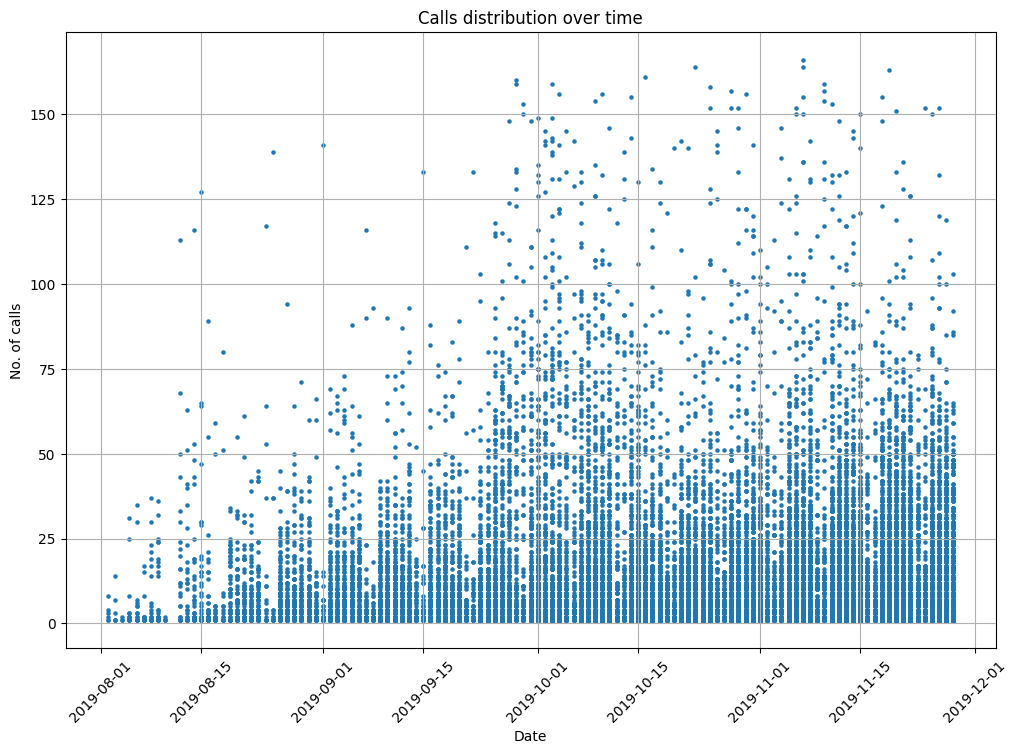

In [24]:
calls.plot(x='date', y='calls_count', title='Calls distribution over time', style='o', xlabel = "Date", ylabel = "No. of calls",
           grid =True, figsize = [12, 8], kind = 'scatter',rot=45, s=5)
plt.show()

Los graficos anteriores muestran que una alta proporción en **tiempo de espera es menor a 500 segundos** y la mayoria de los trabajadores no realizan más de **75 llamadas diarias**. Respecto al volumen de llamadas en el tiempo, puede observarse que el número de llamadas máximo aumenta al pasar de los días, alcanzandose los **máximos históricos** entre el *01-11-2019* y *15-11-2019*.

---

# Estadísticas por operador

In [25]:
# ESTRADÍSTICAS POR OPERADOR PARA LLAMADAS ENTRANTES
op_stats = calls.query("direction == 'in'").groupby('operator_id').agg({
    'calls_count':  'sum', 'is_missed_call':'sum', 'waiting_time': 'mean'})
op_stats.columns = ['total_incom_calls', 'total_missed_calls', 'avg_waiting_time']
op_stats = op_stats.reset_index()
op_stats['avg_waiting_time'] = op_stats['avg_waiting_time'].round(2)
op_stats['missed_incom_rate'] = round(op_stats['total_missed_calls'] / op_stats['total_incom_calls'],4)
#print("Estadísticas por operador para llamadas entrantes:")
#display(op_stats.sample(3))

# ESTADÍSTICAS POR OPERADOR PARA LLAMADAS SALIENTES
op_stats_out = calls.query("direction == 'out'").groupby('operator_id').agg({'calls_count': 'sum'})
op_stats_out.columns = ['total_outgo_calls']
op_stats_out = op_stats_out.reset_index()
#print("Estadísticas por operador para llamadas salientes:")
#display(op_stats_out.sample(3))

# FUSIÓN DE AMBOS DATAFRAMES DE ESTADÍSTICAS POR OPERADOR
op_stats = op_stats.merge(op_stats_out, on='operator_id', how='outer')
op_stats = op_stats.fillna(0)
print("Estadísticas por operador para llamadas entrantes y salientes:")
display(op_stats.sample(3))

Estadísticas por operador para llamadas entrantes y salientes:


,operator_id,total_incom_calls,total_missed_calls,avg_waiting_time,missed_incom_rate,total_outgo_calls
833,910926,0.0,0.0,0.0,0.0,25.0
930,934426,0.0,0.0,0.0,0.0,222.0
1034,952458,0.0,0.0,0.0,0.0,1290.0


---

# Identificación de operadores ineficaces

Percentiles 85, 90, 95 y 99 para la tasa de llamadas perdidas:
0.85    0.01040
0.90    0.02066
0.95    0.05395
0.99    0.20450
Name: missed_incom_rate, dtype: float64


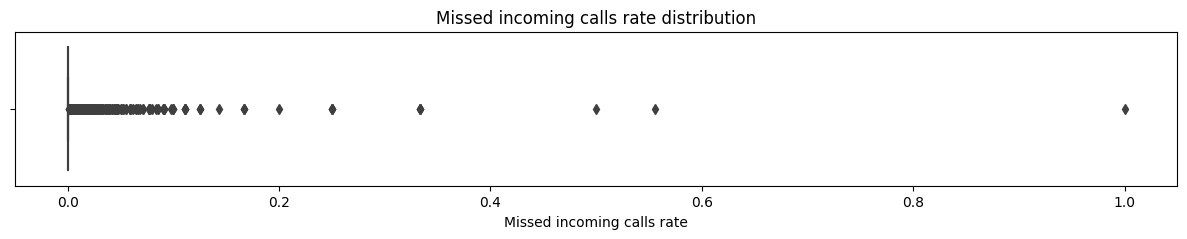

Percentiles 70, 80, 90, 95 y 99 para el tiempo promedio de espera:
0.70     35.3200
0.80     52.1040
0.90     82.6920
0.95    133.2735
0.99    323.8946
Name: avg_waiting_time, dtype: float64


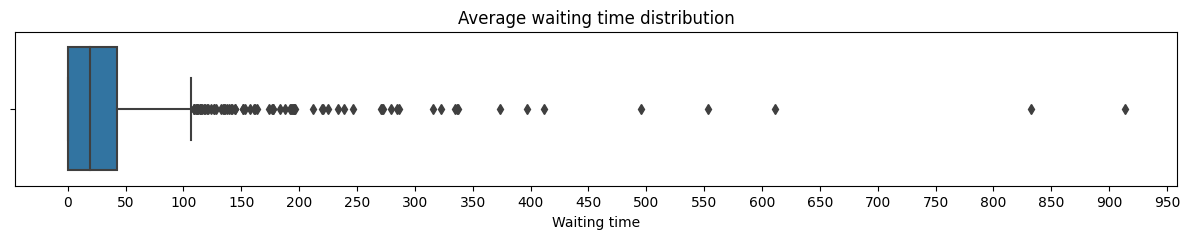

Percentiles 10, 20 y 30 para el total de llamadas salientes:
0.1     3.0
0.2     8.0
0.3    17.0
Name: total_outgo_calls, dtype: float64


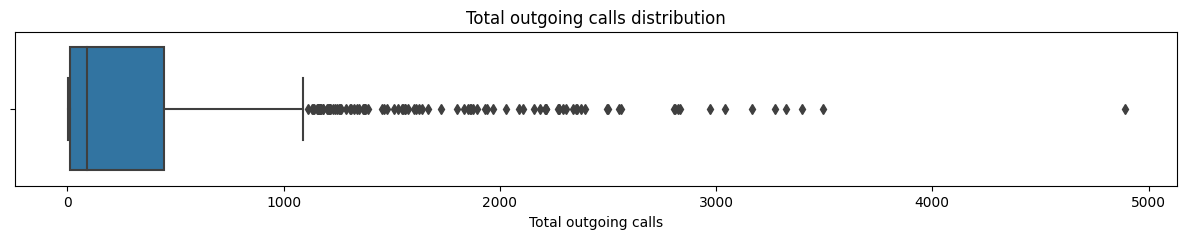

In [26]:
# ANÁLISIS DE PERCENTILES PARA LA DEFINICIÓN DE UMBRALES DE EFICIENCIA

# TASA DE LLAMADAS PERDIDAS
print("Percentiles 85, 90, 95 y 99 para la tasa de llamadas perdidas:")
print(op_stats['missed_incom_rate'].quantile([0.85, 0.9,0.95,0.99]))
plt.figure(figsize=(15,2))
sns.boxplot(data=op_stats, x="missed_incom_rate")
plt.title('Missed incoming calls rate distribution')
plt.xlabel('Missed incoming calls rate')
plt.show()

# TIEMPO DE ESPERA PROMEDIO
print("Percentiles 70, 80, 90, 95 y 99 para el tiempo promedio de espera:")
print(op_stats['avg_waiting_time'].quantile([0.7,0.8,0.9,0.95,0.99]))
plt.figure(figsize=(15,2))
sns.boxplot(data=op_stats, x="avg_waiting_time")
plt.title('Average waiting time distribution')
plt.xlabel('Waiting time')
plt.xticks(list(range(0, 1000, 50)))
plt.show()

# CONTEO TOTAL DE LLAMADAS SALIENTES
print("Percentiles 10, 20 y 30 para el total de llamadas salientes:")
print(op_stats_out['total_outgo_calls'].quantile([0.1,0.20,0.30]))
plt.figure(figsize=(15,2))
sns.boxplot(data=op_stats_out, x="total_outgo_calls")
plt.title('Total outgoing calls distribution')
plt.xlabel('Total outgoing calls')
#plt.xticks(list(range(0, 1000, 50)))
plt.show()

De las estadísticas y figuras previas, se fijan los umbrales de eficiencia como:

- **Tasa de llamadas perdidas:** inferior al $\mathbf{10\%}$.

- **Tiempo de espera promedio:** inferior a $\mathbf{80}$. 

- **Total de llamadas salientes:** superior $\mathbf{8}$. 

Si un operador es ineficiente entrante su **tasa de llamadas perdidas** deberá ser superior al $10\%$ o su **tiempo de espera promedio** debera ser superior a $80$.

Si un un operador es ineficiente saliente su **total de llamadas salientes** deberá ser inferior a $8$.

In [27]:
# IDENTIFICACIÓN DE OPERADORES INEFICACES PARA LLAMADAS ENTRANTES
eficacious_ops_in = op_stats.query('missed_incom_rate < 0.1 and avg_waiting_time < 80')['operator_id'].to_frame()
eficacious_ops_in['uneficacious_in'] = False
# IDENTIFICACIÓN DE OPERADORES INEFICACES PARA LLAMADAS SALIENTES
eficacious_ops_out = op_stats.query('total_outgo_calls >= 8')['operator_id'].to_frame()
eficacious_ops_out['uneficacious_out'] = False
eficacious_ops = eficacious_ops_in.merge(eficacious_ops_out, on='operator_id', how='outer')
op_stats_f = op_stats.merge(eficacious_ops, on='operator_id', how='left')
op_stats_f = op_stats_f.astype({'uneficacious_in': 'bool','uneficacious_out': 'bool','total_incom_calls': 'int',
                               'total_missed_calls': 'int','total_outgo_calls': 'int'})
# SEPARACIÓN DE OPERADORES INEFICACES Y EFICACES
innef_ops = op_stats_f.query('uneficacious_in == True or uneficacious_out == True')[['operator_id','avg_waiting_time',
                                                                        'missed_incom_rate','total_outgo_calls','uneficacious_in',
                                                                        'uneficacious_out']]
eff_ops = op_stats_f.query('uneficacious_in != True and uneficacious_out != True')[['operator_id','avg_waiting_time',
                                                                        'missed_incom_rate','total_outgo_calls']]
eff_op_avg_wait_time = eff_ops['avg_waiting_time'].mean().round(2)
eff_op_miss_rate = eff_ops['missed_incom_rate'].mean().round(4)
eff_op_out_calls = eff_ops['total_outgo_calls'].mean().round(2)

display(op_stats_f.sample(5))
print(op_stats_f.info())

,operator_id,total_incom_calls,total_missed_calls,avg_waiting_time,missed_incom_rate,total_outgo_calls,uneficacious_in,uneficacious_out
890,920928,0,0,0.00,0.0,15,False,False
766,890420,0,0,0.00,0.0,635,False,False
257,909768,14,0,42.00,0.0,0,False,True
469,934188,6,0,34.67,0.0,2,False,True
860,919196,0,0,0.00,0.0,1216,False,False


<class 'pandas.core.frame.DataFrame'>
Int64Index: 1092 entries, 0 to 1091
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   operator_id         1092 non-null   int64  
 1   total_incom_calls   1092 non-null   int64  
 2   total_missed_calls  1092 non-null   int64  
 3   avg_waiting_time    1092 non-null   float64
 4   missed_incom_rate   1092 non-null   float64
 5   total_outgo_calls   1092 non-null   int64  
 6   uneficacious_in     1092 non-null   bool   
 7   uneficacious_out    1092 non-null   bool   
dtypes: bool(2), float64(2), int64(4)
memory usage: 61.9 KB
None


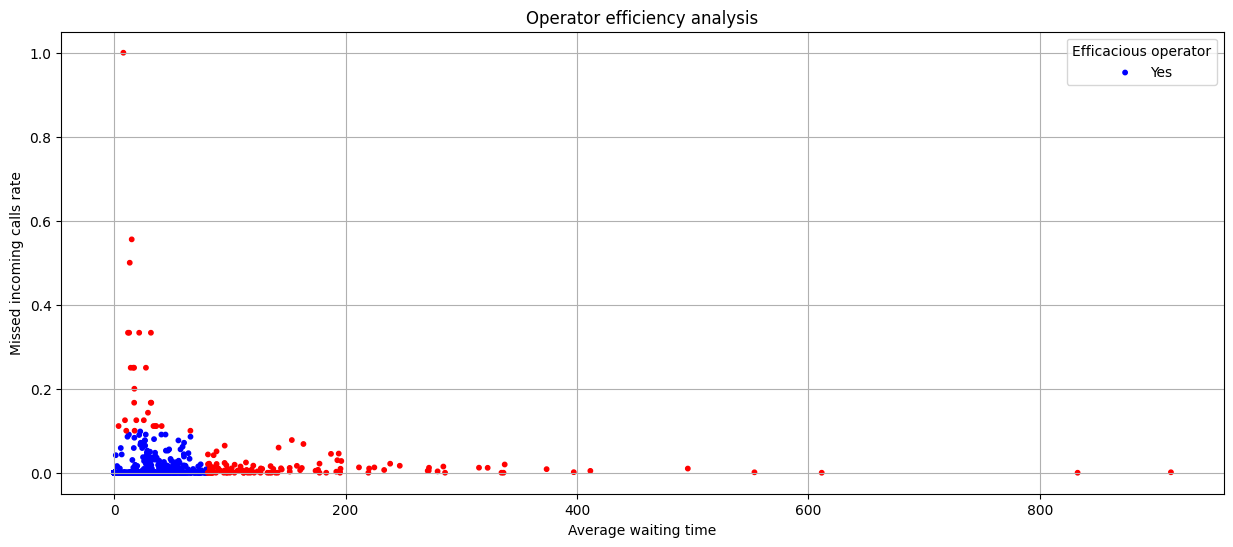

In [28]:
op_stats_f.plot(x='avg_waiting_time', y='missed_incom_rate', kind='scatter', s=10,
                     c=op_stats_f['uneficacious_in'].apply(lambda x: 'blue' if x==False else 'red'),
                     xlabel='Average waiting time', ylabel='Missed incoming calls rate', grid=True, figsize=(15,6))
plt.legend(title='Efficacious operator', labels=['Yes', 'No'])
plt.title('Operator efficiency analysis')
plt.show()

---

# Hipótesis estadísticas

**Hipótesis 1:** "El tiempo de espera promedio para las llamadas *internas* entrantes es menor al tiempo de espera promedio para las llamadas *externas* entrantes."


**Hipótesis 2:** "La tasa de llamadas perdidas de los operadores identificados como 'ineficaces' es significativamente mayor que la del resto de operadores.".


**Hipótesis 3:** "La tasa de llamadas perdidas internas es significativamente diferente a la tasa de llamadas perdidas externas."

### Prueba 1:

Sean $H_0:\,\mu_\text{WT-in}\geq\mu_\text{WT-out}$ y $H_1:\,\mu_\text{WT-in}<\mu_\text{WT-out}$ las hipótesis nula y alternativa. Donde $\mu_\text{WT-in}$ y $\mu_\text{WT-out}$ son las medias del tiempo de espera para llamadas internas y externas respectivamente.

Primero se comprobará la igualdad de varianzas con una prueba de Levene. Posteriormente se aplicará una prueba bilateral para diferencia de medias. En ambos casos se usará una significancia $\alpha=0.05$.

In [29]:
# PRUEBA DE LEVENE

alpha = 0.05
waiting_time_in = calls.query("direction == 'in'")['waiting_time']
waiting_time_out = calls.query("direction == 'out'")['waiting_time']

stat, p_value = st.levene(waiting_time_in, waiting_time_out)

print("Prueba de Levene para igualdad de varianzas entre tiempo de espera de llamadas internas y externas:\n")

print(f"Estadístico de prueba: {stat}")
print(f"Valor-p: {p_value}\n")

if p_value < alpha:
    print("Las varianzas son significativamente diferentes.")
else:
    print("No hay evidencia suficiente para decir que las varianzas son diferentes.")
print("\nPrueba T para diferencia de medias entre tiempo de espera de llamadas internas y externas:\n")

# PRUEBA T PARA DIFERENCIA DE MEDIAS

stat, p_value = st.ttest_ind(waiting_time_in, waiting_time_out, equal_var=False)

print(f"Estadístico de prueba: {stat}")
print(f"Valor-p: {p_value}\n")

if (p_value/2 < alpha) and (waiting_time_in.mean() < waiting_time_out.mean()):
    print("Se rechaza la hipótesis nula.") 
else:
    print("No se rechaza la hipótesis nula.")

Prueba de Levene para igualdad de varianzas entre tiempo de espera de llamadas internas y externas:

Estadístico de prueba: 1381.6294139923846
Valor-p: 2.9161124763751256e-297

Las varianzas son significativamente diferentes.

Prueba T para diferencia de medias entre tiempo de espera de llamadas internas y externas:

Estadístico de prueba: -50.63032758168112
Valor-p: 0.0

Se rechaza la hipótesis nula.


### Prueba 2:

Sean $H_0:\,\mu_\text{innef-in}\leq \mu_\text{eff-in}$ y $H_1:\,\mu_\text{innef-in}>\mu_\text{eff-in}$ las hipótesis nula y alternativa. Donde $\mu_\text{innef-in}$ y $\mu_\text{eff-in}$ son las proporciones de llamadas perdidas de operados ineficientes y eficientes respectivamente.

Primero se comprobará la igualdad de varianzas con una prueba de Levene. Posteriormente se aplicará una prueba bilateral para diferencia de medias. En ambos casos se usará una significancia $\alpha=0.05$.

In [30]:
# PRUEBA DE LEVENE

alpha = 0.05

innef = op_stats_f.query('uneficacious_in == True')['missed_incom_rate']
eff = op_stats_f.query('uneficacious_in == False')['missed_incom_rate']

stat, p_value = st.levene(innef, eff)

print("Prueba de Levene para igualdad de varianzas entre tiempo de espera de llamadas internas y externas:\n")

print(f"Estadístico de prueba: {stat}")
print(f"Valor-p: {p_value}\n")

if p_value < alpha:
    print("Las varianzas son significativamente diferentes.")
else:
    print("No hay evidencia suficiente para decir que las varianzas son diferentes.")
    
print("\nPrueba T para diferencia proporciones de llamadas perdidas entre operadores ineficaces y eficaces:\n")

# PRUEBA T PARA DIFERENCIA DE MEDIAS

stat, p_value = st.ttest_ind(innef, eff, equal_var=False)

print(f"Estadístico de prueba: {stat}")
print(f"Valor-p: {p_value/2}\n")

if p_value/2 < alpha and (innef.mean() > eff.mean()):
    print("Se rechaza la hipótesis nula. Hay evidencia suficiente para afirmar que las medias son diferentes.") 
else:
    print("No se rechaza la hipótesis nula. No hay evidencia suficiente para afirmar que las medias son diferentes.")

Prueba de Levene para igualdad de varianzas entre tiempo de espera de llamadas internas y externas:

Estadístico de prueba: 130.14672268610207
Valor-p: 1.4747456381262018e-28

Las varianzas son significativamente diferentes.

Prueba T para diferencia proporciones de llamadas perdidas entre operadores ineficaces y eficaces:

Estadístico de prueba: 4.801874117438428
Valor-p: 1.931047160294555e-06

Se rechaza la hipótesis nula. Hay evidencia suficiente para afirmar que las medias son diferentes.


### Prueba 3:

Sean $H_0:\,\mu_\text{miss-in}= \mu_\text{miss-ex}$ y $H_1:\,\mu_\text{miss-in}\neq\mu_\text{miss-in}$ las hipótesis nula y alternativa. Donde $\mu_\text{miss-in}$ y $\mu_\text{miss-ex}$ son las tasas de llamadas perdidas de internas y externas respectivamente.

In [31]:
# PRUEBA DE DIFERENCIA DE PROPORCIONES PARA LAS LLAMADAS PERDIDAS INTERNAS Y EXTERNAS

alpha = 0.05

miss_in = calls.query("internal == True")['is_missed_call']
miss_ex = calls.query("internal == False")['is_missed_call']

total_in_calls = len(calls.query("internal == True"))
total_ex_calls = len(calls.query("internal == False"))

p_miss_in = miss_in.sum() / total_in_calls
p_miss_ex = miss_ex.sum() / total_ex_calls
    
p_combined = (miss_in.sum() + miss_ex.sum()) / (total_in_calls + total_ex_calls)
difference = p_miss_in - p_miss_ex

z_value = difference / mt.sqrt(p_combined * (1 - p_combined) * (1/total_in_calls + 1/total_ex_calls))
p_value = 2 * (1 - st.norm.cdf(abs(z_value)))

print("\nPrueba para diferencia de proporciones en llamadas perdidas internas y externas:\n")
print(f"Estadístico de prueba (z): {z_value}")
print(f"Valor-p: {p_value}\n")

if (p_value < alpha) :
    print("Rechazar la hipótesis nula")
else:
    print("No se pudo rechazar la hipótesis nula")



Prueba para diferencia de proporciones en llamadas perdidas internas y externas:

Estadístico de prueba (z): 16.31167144737258
Valor-p: 0.0

Rechazar la hipótesis nula


### Conclusion de las pruebas

- **Conclusión para prueba 1:** El tiempo de espera promedio para las llamadas *internas* entrantes es inferior al tiempo de espera promedio para las llamadas *externas* entrantes.


- **Conclusión para prueba 2:** La tasa de llamadas perdidas de los operadores identificados como 'ineficaces' es significativamente mayor que la del resto de operadores.


- **Conclusión para prueba 3:** La tasa de llamadas perdidas internas es significativamente diferente a la tasa de llamadas perdidas externas.

---

# Conclusiones y Recomendaciones Clave

Tras el análisis exploratorio de datos y la prueba de hipótesis, se han identificado patrones de rendimiento significativos y áreas de mejora para la eficiencia operativa.

## Hallazgos principales

1. **Prioridad: Tiempos de espera en llamadas externas**
   La prueba de hipótesis concluye que se debe priorizar la atención en los tiempos de espera de las llamadas externas. Este tiempo es significativamente superior al de las llamadas internas, un hallazgo crítico dado que las llamadas externas representan la mayor proporción de las interacciones gestionadas por los operadores.

2. **Línea base de operadores eficientes**
   Para establecer un punto de referencia, los operadores considerados "eficientes" mantienen las siguientes métricas de rendimiento:

   * **Tiempo de espera promedio:** 18.68 segundos

   * **Tasa de llamadas perdidas:** 0.49%

   * **Media de llamadas salientes:** 441.38

3. **Identificación de operadores ineficaces**
   Se ha compilado una lista de operadores cuyas métricas de rendimiento caen por debajo de la línea base de eficiencia establecida.

   * Las estadísticas detalladas de estos operadores pueden consultarse en el siguiente enlace: [Listado de Operadores Ineficaces](https://drive.google.com/file/d/1IqC10srtmDps5TYTB6mXi40wJolup0ef/view?usp=sharing).

4. **Dashboard**
   Un dashboard con los resultados del proyecto se puede consultar [aquí](https://public.tableau.com/views/inef_ops/CallMeMaybe-Ops?:language=en-US&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)

## Recomendaciones accionables

1. **Capacitación e envestigación de inefectividad**
   Se sugiere investigar las razones subyacentes de la "inefectividad" de los operadores identificados en el listado. Con base en estos hallazgos, se recomienda implementar programas de capacitación focalizados en optimizar los tiempos de respuesta y reducir la duración promedio de atención por llamada.

2. **Análisis de casos atípicos**
   Se recomienda fuertemente explorar las causas de los valores atípicos detectados en el análisis, particularmente aquellos relacionados con tiempos de espera extremos y llamadas con duraciones excesivamente largas. Comprender estos casos podría revelar problemas sistémicos o cuellos de botella específicos en el proceso de atención.

## Enlaces

- [Carpeta general](https://drive.google.com/drive/folders/1DXKwkkoo_r8rvja4bi2FtllZljDbeYyJ?usp=drive_link)
- [Código original](https://drive.google.com/file/d/1kUgbK0mgFRsD4tFJ5ROPMLgA8KJAu0fv/view?usp=drive_link)
- [Presentación de resultados](https://drive.google.com/file/d/1RRTbozguSzGNB4BNhTMEjHP-75_Sp3Hs/view?usp=drive_link)
- [Dashboard (Tableau Public)](https://public.tableau.com/views/inef_ops/CallMeMaybe-Ops?:language=en-US&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)